In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [2]:
X = 6 * np.random.rand(200, 1) - 3
# range  of values: [0, 1] -> [0, 6] -> [-3, 3]

# np.random.randn(200, 1) -> Generates Gaussian noise: mean = 0, std ≈ 1
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

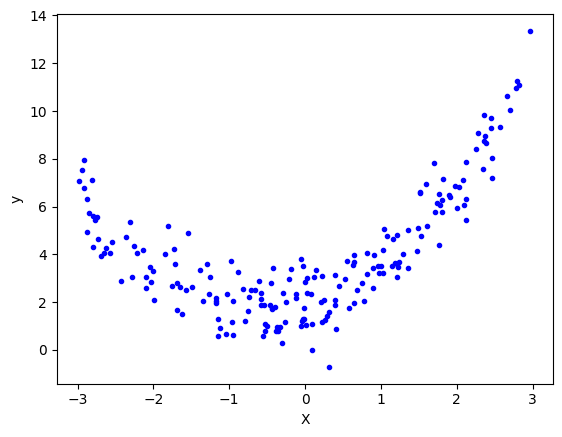

In [3]:
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## 4. Train-Test Split

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
lr = LinearRegression()

In [6]:
lr.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = lr.predict(X_test)

In [8]:
r2_score(y_test, y_pred)

0.2581780954525196

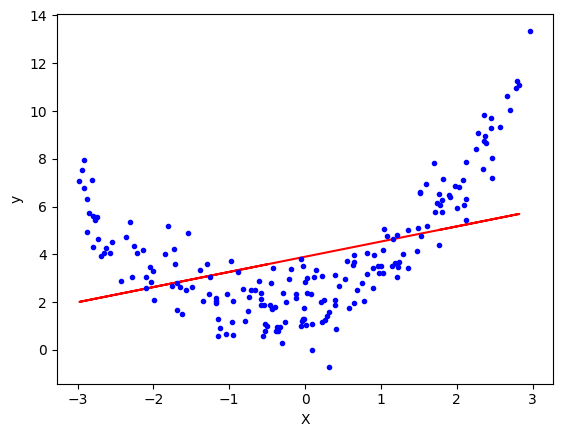

In [9]:
plt.plot(X_train, lr.predict(X_train), color="r")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [10]:
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [11]:
print("X_train shape:",X_train.shape, X_train[0])

print("X_train_trans shape:",X_train_trans.shape, X_train_trans[0])

X_train shape: (160, 1) [1.77982782]
X_train_trans shape: (160, 3) [1.         1.77982782 3.16778706]


In [12]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(X_test_trans)

In [14]:
r2_score(y_test, y_pred)

0.8825394901354897

In [15]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.88714925 0.78108711]]
[1.96485695]


In [16]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

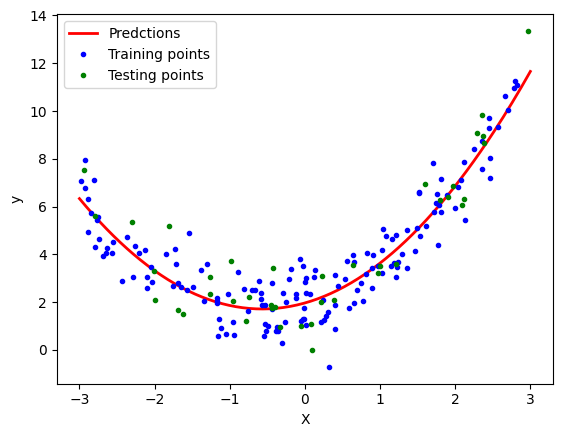

In [17]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predctions")
plt.plot(X_train, y_train, "b.", label="Training points")
plt.plot(X_test, y_test, "g.", label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [20]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)
    
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg)
    ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, "r", label="Degree " + str(degree), linewidth=2)
    
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend(loc="upper left")
    plt.axis([-3, 3, 0, 10])
    plt.show()

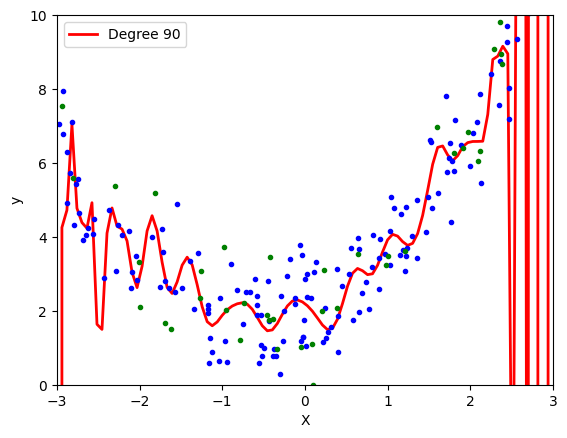

In [26]:
polynomial_regression(90)